In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm import tqdm

jax.config.update("jax_enable_x64", True)

from JAX_BSSN.evolve import rk4_step
from JAX_BSSN.bssn import BSSNVariables, BSSNParameters, compute_momentum_constraint
from JAX_BSSN.errors import compute_hamiltonian_constraint
from JAX_BSSN.derivatives import diff1_field
from JAX_BSSN.tensor_algebra import (
    invert_3x3_metric,
    christoffel_symbols_second_kind,
    trace_tensor,
    traceless_part,
)

The goal of this notebook is to use JAX_BSSN to build the BSSN variables for a static mass density in flat spacetime.

We start by defining a function to create a spherical mass density. The functionality of this is shown below using an example with slices in the xy, yz, and xz plane.

In [2]:
radius = 6.378 # Megameter
density = 5.513e-3 # kg/Mm^3

x = jnp.linspace(0, radius * 2, 50)
y = jnp.linspace(0, radius * 2, 50)
z = jnp.linspace(0, radius * 2, 50)

X, Y, Z = jnp.meshgrid(x, y, z, indexing='ij')

rho = jnp.where((X - 6.378)**2 + (Y - 6.378)**2 + (Z - 6.378)**2 < radius**2, density, 0)

def compute_rho_sphere(x, y, z, center, radius, uniform_density):
    center_x, center_y, center_z = center
    X, Y, Z = jnp.meshgrid(x, y, z, indexing='ij')
    rho = jnp.where((X - center_x)**2 + (Y - center_y)**2 + (Z - center_z)**2 < radius**2, uniform_density, 0)
    return rho

We also define a way to visualize slices of the spherical mass density in the xy, yz, and xz plane.

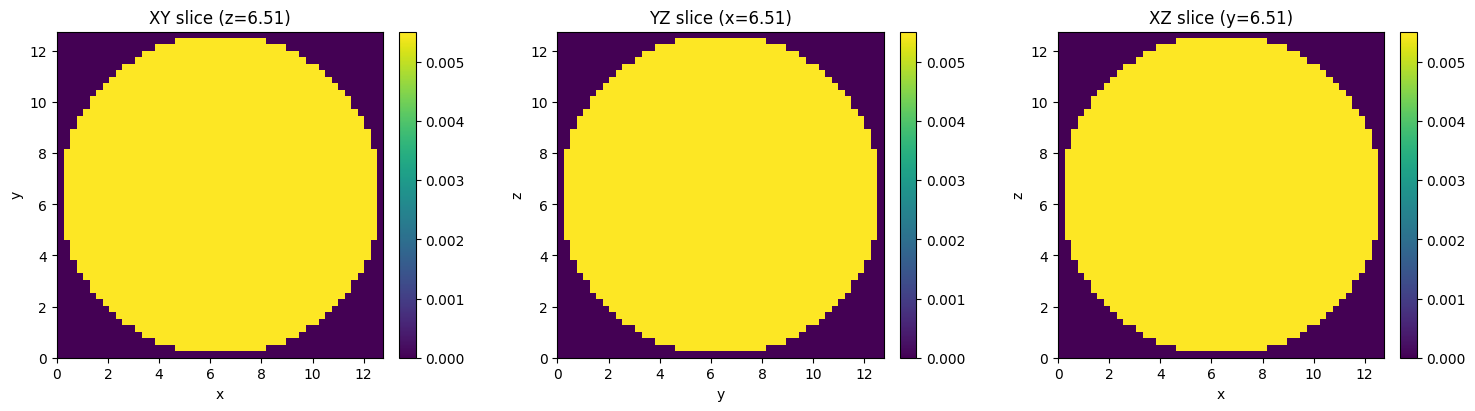

In [10]:
# Choose central slices (closest to coordinate 5)
ix = jnp.argmin(jnp.abs(x - 6.378))
iy = jnp.argmin(jnp.abs(y - 6.378))
iz = jnp.argmin(jnp.abs(z - 6.378))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

# XY slice at fixed z
im0 = axes[0].imshow(
    rho[:, :, iz].T,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap="viridis",
    aspect="equal"
)
axes[0].set_title(f"XY slice (z={z[iz]:.2f})")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# YZ slice at fixed x
im1 = axes[1].imshow(
    rho[ix, :, :].T,
    origin="lower",
    extent=[y.min(), y.max(), z.min(), z.max()],
    cmap="viridis",
    aspect="equal"
)
axes[1].set_title(f"YZ slice (x={x[ix]:.2f})")
axes[1].set_xlabel("y")
axes[1].set_ylabel("z")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# XZ slice at fixed y
im2 = axes[2].imshow(
    rho[:, iy, :].T,
    origin="lower",
    extent=[x.min(), x.max(), z.min(), z.max()],
    cmap="viridis",
    aspect="equal"
)
axes[2].set_title(f"XZ slice (y={y[iy]:.2f})")
axes[2].set_xlabel("x")
axes[2].set_ylabel("z")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()

Next, we define a stress-energy tensor function for our rho and compute it.

In [11]:
def generate_stress_energy_tensor(rho):
    T = jnp.zeros((4, 4) + rho.shape)  # 4D array
    T = T.at[0, 0].set(rho)  # T_00 is mass density
    return T
T = generate_stress_energy_tensor(rho)

We will now run JAX_BSSN on a rho and try to recover newtonian potential from the lapse. We first must define relevant measurements to simulate the earth. We work in Mm and geometric units:

In [ ]:
# --- Unit conversion to geometric units (G = c = 1) ---
#
# The BSSN code works in geometric units where lengths are in Mm.
# Earth density: 5513 kg/m^3 = 5.513e+21 kg/Mm^3  (since 1 Mm^3 = 1e18 m^3)
#
# To convert mass density to geometric units (1/Mm^2):
#   rho_geom = (G / c^2) * rho_SI   [in appropriate length units]
#
# G = 6.674e-11 m^3 kg^-1 s^-2
# c = 2.998e8   m s^-1
# G/c^2 = 7.426e-28 m/kg
#       = 7.426e-34 Mm/kg
#
# Earth:  rho_SI = 5513 kg/m^3 = 5.513e21 kg/Mm^3
#   rho_geom = 7.426e-34 * 5.513e21 = 4.094e-12  Mm^-2

G_SI = 6.67430e-11          # m^3 kg^-1 s^-2
c_SI = 2.99792458e8         # m s^-1
Mm   = 1.0e6                # m per Mm

G_over_c2_Mm = G_SI / (c_SI**2 * Mm)   # Mm / kg

R_sphere = 6.378            # Mm  (Earth radius)
rho_SI_Mm3 = 5.513e21       # kg/Mm^3

rho_geom = G_over_c2_Mm * rho_SI_Mm3   # Mm^-2 (geometric units)

M_sphere = (4.0/3.0) * jnp.pi * R_sphere**3 * rho_SI_Mm3   # kg
M_geom   = G_over_c2_Mm * M_sphere * Mm  # dimensionless (in Mm units, G=c=1 means M in Mm)

# In full geometric units with length unit = Mm:
# G_geom = G_SI / (c_SI^2 * Mm) * (c_SI^2 / Mm) ... 
# Simpler: use the conversion factor directly
# rho_geom has units 1/Mm^2 in the BSSN equations

print(f'Earth density (SI):        {rho_SI_Mm3:.4e} kg/Mm^3')
print(f'G/c^2 (Mm/kg):             {G_over_c2_Mm:.4e}')
print(f'rho_geom (1/Mm^2):         {rho_geom:.4e}')
print(f'Sphere mass:               {float(M_sphere):.4e} kg')
print(f'Phi/c^2 at surface ~ GM/(c^2 R) = {float(G_over_c2_Mm * M_sphere / R_sphere):.4e}')


Earth density (SI):        5.5130e+21 kg/Mm^3
G/c^2 (Mm/kg):             7.4262e-34
rho_geom (1/Mm^2):         4.0940e-12
Sphere mass:               5.9914e+24 kg
Phi/c^2 at surface ~ GM/(c^2 R) = 6.9761e-10


Next we define a function to run JAX_BSSN on a static planetary mass. We will be using the lapse and metric

$$\alpha = 1, d\sigma^{2}=\gamma_{\mu  \nu}dx^{\mu}dx^{\mu}$$

where the lapse represents a static spacetime and the flat metric is defined for the Minkowski spacetime metric.

We now define our simulation function:

In [4]:
def run_static_mass(nx, L, dt_factor, Nt, snapshot_stride, rho_field_fn,
                    show_progress=True):
    """Evolve flat spacetime + spherical mass density in 3D BSSN.

    Initialises Minkowski initial data (alpha=1, flat metric, K=0)
    with a caller-supplied density field.

    Parameters
    ----------
    rho_field_fn : callable(coords) -> array (nx, nx, nx)
        Function that takes the 1-D coordinate array and returns the
        mass-density field in geometric units.
    """
    dx = L / nx
    dt = dt_factor * dx
    coords = -L/2 + (jnp.arange(nx) + 0.5) * dx  # cell-centred

    # Build the density on this grid via the user-supplied function
    rho_field = rho_field_fn(coords)

    x3d, y3d, z3d = jnp.meshgrid(coords, coords, coords, indexing='ij')
    r3d = jnp.sqrt(x3d**2 + y3d**2 + z3d**2)
    r3d = jnp.maximum(r3d, 1e-30)

    # Flat-space BSSN initial data
    alpha = jnp.ones((nx, nx, nx))
    beta  = jnp.zeros((3, nx, nx, nx))
    conformal_factor = jnp.ones((nx, nx, nx))

    gamma = jnp.zeros((3, 3, nx, nx, nx))
    gamma = gamma.at[0, 0].set(1.0)
    gamma = gamma.at[1, 1].set(1.0)
    gamma = gamma.at[2, 2].set(1.0)

    traceless_K = jnp.zeros((3, 3, nx, nx, nx))
    trace_K     = jnp.zeros((nx, nx, nx))
    conformal_connection = jnp.zeros((3, nx, nx, nx))

    vars = BSSNVariables(
        conformal_metric=gamma,
        conformal_factor=conformal_factor,
        traceless_K=traceless_K,
        trace_K=trace_K,
        conformal_connection=conformal_connection,
        lapse=alpha,
        shift=beta,
        rho=rho_field,
    )

    params = BSSNParameters(
        eta=0.0,
        kappa=0.0,
        nu=0.25,
        f=1.0,      # 1+log slicing -> lapse settles to ~ 1 + Phi/c^2
        g=0.0,
        dx=dx,
        dt=dt,
    )

    # Snapshot storage
    times_list = [0.0]
    lapse_snapshots = [vars.lapse]

    iterator = range(1, Nt + 1)
    if show_progress:
        iterator = tqdm(iterator, leave=False)

    for step in iterator:
        vars = rk4_step(vars, params)
        if (step % snapshot_stride == 0) or (step == Nt):
            times_list.append(step * dt)
            lapse_snapshots.append(vars.lapse)

    return (
        jnp.asarray(times_list),
        lapse_snapshots,
        coords,
        r3d,
        rho_field,
        dx,
    )


We now define our our resolution factors and center our computed rho before running our simulation. Be wary of edits, it currently takes almost 3.75 hours to complete a simulation at this resolution but it is the only resolution which has given me a nonzero result for the lapse.

In [ ]:
# Run the static-mass evolution
L_domain = 4.0 * R_sphere    # ~25.5 Mm
nx_mass  = 64                 
dt_fac   = 0.1                # CFL factor
Nt_mass  = 1000               # 10^3 timesteps
snap_stride = 100

# Build rho_field using compute_rho_sphere from cell 4
def make_rho_field(coords):
    """Create spherical density field centred at origin using compute_rho_sphere."""
    return compute_rho_sphere(
        coords, coords, coords,
        center=(0.0, 0.0, 0.0),
        radius=R_sphere,
        uniform_density=rho_geom,
    )

print(f'Domain: [{-L_domain/2:.2f}, {L_domain/2:.2f}] Mm   ({nx_mass}^3 grid)')
print(f'dx = {L_domain/nx_mass:.4f} Mm,  dt = {dt_fac * L_domain/nx_mass:.4e} Mm')
print(f'Nt = {Nt_mass},  rho_geom = {rho_geom:.4e} Mm^-2')

times_mass, lapse_snaps, coords_mass, r3d_mass, rho_field_mass, dx_mass = run_static_mass(
    nx=nx_mass,
    L=L_domain,
    dt_factor=dt_fac,
    Nt=Nt_mass,
    snapshot_stride=snap_stride,
    rho_field_fn=make_rho_field,
    show_progress=True,
)

print(f'\nEvolution finished: {len(times_mass)} snapshots over t=[0, {float(times_mass[-1]):.4f}] Mm')


Domain: [-12.76, 12.76] Mm   (64^3 grid)
dx = 0.3986 Mm,  dt = 3.9863e-02 Mm
Nt = 1000,  rho_geom = 4.0940e-12 Mm^-2



Evolution finished: 11 snapshots over t=[0, 39.8625] Mm


We finally compare our code to the newtonian potential in linearized gravity.

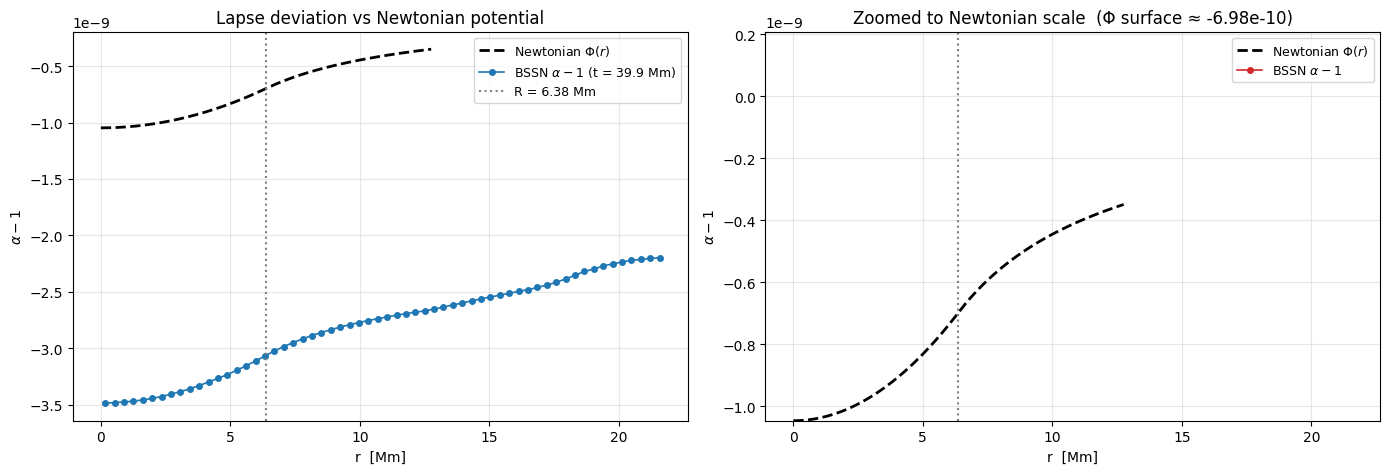


--- Precision diagnostic ---
Newtonian Φ(R_surface) = -6.9761e-10
BSSN (α-1) at surface  = -3.0690e-09
float64 epsilon at 1.0 = 2.22e-16
Signal / float64 eps   = 3141736.3


In [9]:
# --- Compare final lapse to Newtonian prediction (ZOOMED) ---
import numpy as np

# ---- Newtonian potential computed in float64 (avoids sqrt(1+2Phi)-1 cancellation) ----
M_geom_sphere_f64 = np.float64(4.0/3.0) * np.pi * np.float64(R_sphere)**3 * np.float64(rho_geom)

def newtonian_potential_f64(r, M, R):
    """Phi(r) for a uniform sphere, in float64."""
    inside  = -M / (2.0 * R) * (3.0 - r**2 / R**2)
    outside = -M / r
    return np.where(r <= R, inside, outside)

r_ref = np.linspace(0.01, 2.0 * float(R_sphere), 500)
Phi_ref_f64 = newtonian_potential_f64(r_ref, M_geom_sphere_f64, float(R_sphere))
# In linearised gravity, alpha ≈ 1 + Phi, so (alpha-1) ≈ Phi
alpha_dev_newton = Phi_ref_f64   # this IS the expected (alpha - 1) to leading order

# ---- BSSN radial lapse profile ----
alpha_final = np.asarray(lapse_snaps[-1], dtype=np.float64)
r_flat = np.asarray(r3d_mass).ravel()
a_flat = alpha_final.ravel()

n_bins = 60
r_edges = np.linspace(0, float(r_flat.max()), n_bins + 1)
r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
bin_idx = np.digitize(r_flat, r_edges) - 1
alpha_radial = np.array([
    a_flat[bin_idx == i].mean() if np.any(bin_idx == i) else np.nan
    for i in range(n_bins)
])
bssn_dev = alpha_radial - 1.0

# ---- Plots ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: lapse deviation (alpha - 1)
axes[0].plot(r_ref, alpha_dev_newton, 'k--', lw=2,
             label=r'Newtonian $\Phi(r)$')
axes[0].plot(r_centers, bssn_dev, 'o-', ms=4, lw=1.2,
             label=f'BSSN $\\alpha - 1$ (t = {float(times_mass[-1]):.1f} Mm)')
axes[0].axvline(float(R_sphere), ls=':', color='grey', label=f'R = {float(R_sphere):.2f} Mm')
axes[0].set_xlabel('r  [Mm]')
axes[0].set_ylabel(r'$\alpha - 1$')
axes[0].set_title('Lapse deviation vs Newtonian potential')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: zoom — force y-axis to Newtonian scale
Phi_surface = newtonian_potential_f64(np.array([float(R_sphere)]),
                                       M_geom_sphere_f64, float(R_sphere))[0]
y_lo = 1.5 * Phi_surface  # ~-1.5e-9 (negative, so 1.5× makes it more negative)
y_hi = -0.3 * Phi_surface  # small positive offset
axes[1].plot(r_ref, alpha_dev_newton, 'k--', lw=2, label=r'Newtonian $\Phi(r)$')
axes[1].plot(r_centers, bssn_dev, 'o-', ms=4, lw=1.2, color='tab:red',
             label=f'BSSN $\\alpha - 1$')
axes[1].axvline(float(R_sphere), ls=':', color='grey')
axes[1].set_ylim(y_lo, y_hi)
axes[1].set_xlabel('r  [Mm]')
axes[1].set_ylabel(r'$\alpha - 1$')
axes[1].set_title(f'Zoomed to Newtonian scale  (Φ surface ≈ {Phi_surface:.2e})')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n--- Precision diagnostic ---')
print(f'Newtonian Φ(R_surface) = {Phi_surface:.4e}')
bssn_surface_idx = np.argmin(np.abs(r_centers - float(R_sphere)))
print(f'BSSN (α-1) at surface  = {bssn_dev[bssn_surface_idx]:.4e}')
print(f'float64 epsilon at 1.0 = {np.finfo(np.float64).eps:.2e}')
print(f'Signal / float64 eps   = {abs(Phi_surface) / np.finfo(np.float64).eps:.1f}')
